<a href="https://colab.research.google.com/github/charlesbihdev/charlesbihdev-ML-DataScience-Notebooks/blob/1Data_Analysis/1Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [120]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


#init plotly in jupyte notebook
import plotly.io as pio

In [ ]:
df = pd.read_csv(r"/train.csv")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
#filling null values

In [ ]:
df['Postal Code'].fillna(0, inplace=True)

<ipython-input-12-fc0678e69917>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Postal Code'].fillna(0, inplace=True)


In [ ]:
df['Postal Code'] = df['Postal Code'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9800 non-null   int64  
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
if df.duplicated().sum() > 0:
  print("Duplicate exist")
else:
  print("Doesn't Exist")

Doesn't Exist


In [ ]:
#types of customers
types_of_customers = df['Segment'].unique()
print(types_of_customers)

['Consumer' 'Corporate' 'Home Office']


In [ ]:
number_of_customers = df['Segment'].value_counts().reset_index()
number_of_customers = number_of_customers.rename(columns={'Segment': 'Type of Customer'})
# number_of_customers.columns = ['Segment', 'Count']
print(number_of_customers)

  Type of Customer  count
0         Consumer   5101
1        Corporate   2953
2      Home Office   1746


([<matplotlib.patches.Wedge at 0x7cbdbb001450>,
 [Text(-0.07082912490696024, 1.0977172837597642, 'Consumer'),
  Text(-0.5228074564626142, -0.9678183525161589, 'Corporate'),
  Text(0.9321462195039758, -0.5840406025820858, 'Home Office')],
 [Text(-0.03863406813106921, 0.5987548820507803, '52.1%'),
  Text(-0.28516770352506227, -0.5279009195542684, '30.1%'),
  Text(0.508443392456714, -0.3185676014084104, '17.8%')])

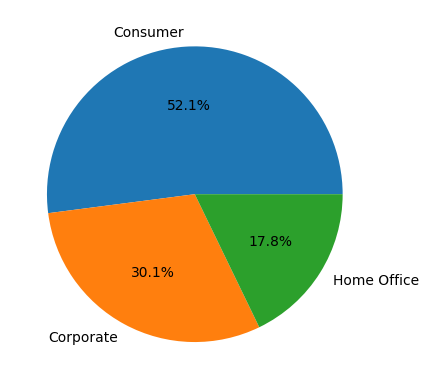

In [ ]:
plt.pie(number_of_customers['count'], labels=number_of_customers['Type of Customer'], autopct='%1.1f%%')

  Type of Customer   Total Sales
0         Consumer  1.148061e+06
1        Corporate  6.884941e+05
2      Home Office  4.249822e+05


<BarContainer object of 3 artists>

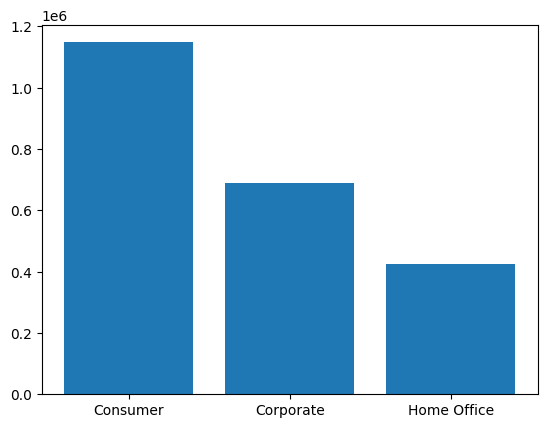

In [ ]:
sales_per_segment = df.groupby('Segment')['Sales'].sum().reset_index()
sales_per_segment = sales_per_segment.rename(columns={'Segment': 'Type of Customer', 'Sales': 'Total Sales'})
print(sales_per_segment)

plt.bar(sales_per_segment['Type of Customer'], sales_per_segment['Total Sales'])

([<matplotlib.patches.Wedge at 0x7cbdb9b83a10>,
 [Text(-0.026420901678353936, 1.099682652384088, 'Consumer'),
  Text(-0.5902004249314667, -0.9282582929393717, 'Corporate'),
  Text(0.9138143750681164, -0.6123261287246105, 'Home Office')],
 [Text(-0.01441140091546578, 0.5998269013004115, '50.8%'),
  Text(-0.3219275045080727, -0.5063227052396572, '30.4%'),
  Text(0.49844420458260885, -0.3339960702134238, '18.8%')])

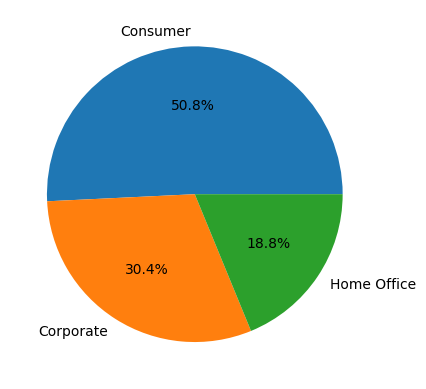

In [ ]:
plt.pie(sales_per_segment['Total Sales'], labels=sales_per_segment['Type of Customer'], autopct='%1.1f%%')

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
customer_order_frequency = df.groupby(['Customer ID', 'Customer Name', 'Segment'])['Order ID'].count().reset_index()
customer_order_frequency.rename(columns={'Order ID': 'Total Orders'}, inplace=True)
print(customer_order_frequency)

    Customer ID       Customer Name    Segment  Total Orders
0      AA-10315          Alex Avila   Consumer            11
1      AA-10375        Allen Armold   Consumer            15
2      AA-10480        Andrew Allen   Consumer            12
3      AA-10645       Anna Andreadi   Consumer            18
4      AB-10015       Aaron Bergman   Consumer             6
..          ...                 ...        ...           ...
788    XP-21865        Xylona Preis   Consumer            28
789    YC-21895      Yoseph Carroll  Corporate             8
790    YS-21880       Yana Sorensen  Corporate            12
791    ZC-21910    Zuschuss Carroll   Consumer            31
792    ZD-21925  Zuschuss Donatelli   Consumer             9

[793 rows x 4 columns]


In [ ]:
repeat_customers = customer_order_frequency[customer_order_frequency['Total Orders'] >= 1]
print(customer_order_frequency)


    Customer ID       Customer Name    Segment  Total Orders
0      AA-10315          Alex Avila   Consumer            11
1      AA-10375        Allen Armold   Consumer            15
2      AA-10480        Andrew Allen   Consumer            12
3      AA-10645       Anna Andreadi   Consumer            18
4      AB-10015       Aaron Bergman   Consumer             6
..          ...                 ...        ...           ...
788    XP-21865        Xylona Preis   Consumer            28
789    YC-21895      Yoseph Carroll  Corporate             8
790    YS-21880       Yana Sorensen  Corporate            12
791    ZC-21910    Zuschuss Carroll   Consumer            31
792    ZD-21925  Zuschuss Donatelli   Consumer             9

[793 rows x 4 columns]


In [ ]:
repeat_customers_sorted = repeat_customers.sort_values(by='Total Orders', ascending=False)
print(repeat_customers_sorted)

    Customer ID      Customer Name      Segment  Total Orders
787    WB-21850      William Brown     Consumer            35
606    PP-18955         Paul Prost  Home Office            34
482    MA-17560       Matt Abelman  Home Office            34
387    JL-15835           John Lee     Consumer            33
720    SV-20365        Seth Vernon     Consumer            32
..          ...                ...          ...           ...
145    CJ-11875       Carl Jackson    Corporate             1
42     AO-10810  Anthony O'Donnell    Corporate             1
456    LD-16855       Lela Donovan    Corporate             1
637    RE-19405    Ricardo Emerson     Consumer             1
403    JR-15700     Jocasta Rupert     Consumer             1

[793 rows x 4 columns]


In [ ]:
customer_sales = df.groupby(['Customer ID', 'Customer Name', 'Segment'])['Sales'].sum().reset_index()
customer_sales.rename(columns={'Sales': 'Total Sales'}, inplace=True)
top_spenders = customer_sales.sort_values(by= 'Total Sales', ascending=False)

top_spenders.head(12).reset_index(drop=True)

,Customer ID,Customer Name,Segment,Total Sales
0,SM-20320,Sean Miller,Home Office,25043.050
1,TC-20980,Tamara Chand,Corporate,19052.218
2,RB-19360,Raymond Buch,Consumer,15117.339
3,TA-21385,Tom Ashbrook,Home Office,14595.620
4,AB-10105,Adrian Barton,Consumer,14473.571
5,KL-16645,Ken Lonsdale,Consumer,14175.229
6,SC-20095,Sanjit Chand,Consumer,14142.334
7,HL-15040,Hunter Lopez,Consumer,12873.298
8,SE-20110,Sanjit Engle,Consumer,12209.438
9,CC-12370,Christopher Conant,Consumer,12129.072


In [ ]:
shipping_model = df['Ship Mode'].value_counts().reset_index()
shipping_model = shipping_model.rename(columns={'count': 'Use Frequency', 'Ship Mode': 'Mode of Shipment'})
print(shipping_model)

  Mode of Shipment  Use Frequency
0   Standard Class           5859
1     Second Class           1902
2      First Class           1501
3         Same Day            538


([<matplotlib.patches.Wedge at 0x7cbdb4b11f10>,
 [Text(-0.33286822443706726, 1.0484267953272248, 'Standard Class'),
  Text(-0.37327504859675137, -1.034729789894489, 'Second Class'),
  Text(0.7455147818297655, -0.8088310763523601, 'First Class'),
  Text(1.083680824088883, -0.18877465799741078, 'Same Day')],
 [Text(-0.18156448605658213, 0.5718691610875771, '59.8%'),
  Text(-0.20360457196186435, -0.5643980672151757, '19.4%'),
  Text(0.4066444264525993, -0.44118058710128727, '15.3%'),
  Text(0.5910986313212089, -0.10296799527131496, '5.5%')])

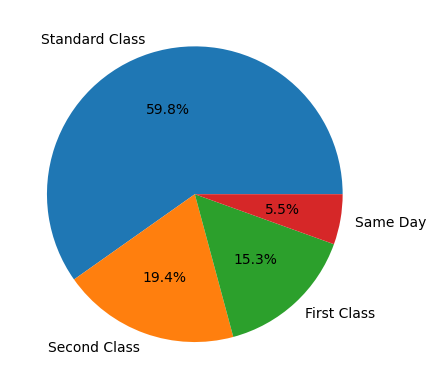

In [ ]:
plt.pie(shipping_model['Use Frequency'], labels=shipping_model['Mode of Shipment'], autopct='%1.1f%%')

In [ ]:
state = df['State'].value_counts().reset_index()
state.rename(columns={'count': 'Number of Customers', 'State': 'State'}, inplace=True)
print(state.sort_values(by='Number of Customers', ascending=False))

                   State  Number of Customers
0             California                 1946
1               New York                 1097
2                  Texas                  973
3           Pennsylvania                  582
4             Washington                  504
5               Illinois                  483
6                   Ohio                  454
7                Florida                  373
8               Michigan                  253
9         North Carolina                  247
10              Virginia                  224
11               Arizona                  223
12             Tennessee                  183
13              Colorado                  179
14               Georgia                  177
15              Kentucky                  137
16               Indiana                  135
17         Massachusetts                  135
18                Oregon                  122
19            New Jersey                  122
20              Maryland          

In [ ]:
products_category = df['Category'].unique()

print(products_category)

['Furniture' 'Office Supplies' 'Technology']


In [ ]:
products_subcategory = df['Sub-Category'].unique()

print(products_subcategory)

['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


In [ ]:
subcategory_count = df.groupby('Category')['Sub-Category'].nunique().reset_index().sort_values(by='Sub-Category', ascending=False)
subcategory_count.rename(columns={'Sub-Category': 'Number of Sub-Categories'}, inplace=True)
print(subcategory_count)

          Category  Number of Sub-Categories
1  Office Supplies                         9
0        Furniture                         4
2       Technology                         4


           Category Sub-Category  Total Sales
16       Technology       Phones  327782.4480
1         Furniture       Chairs  322822.7310
11  Office Supplies      Storage  219343.3920
3         Furniture       Tables  202810.6280
6   Office Supplies      Binders  200028.7850
15       Technology     Machines  189238.6310
13       Technology  Accessories  164186.7000
14       Technology      Copiers  146248.0940
0         Furniture    Bookcases  113813.1987
4   Office Supplies   Appliances  104618.4030
2         Furniture  Furnishings   89212.0180
10  Office Supplies        Paper   76828.3040
12  Office Supplies     Supplies   46420.3080
5   Office Supplies          Art   26705.4100
7   Office Supplies    Envelopes   16128.0460
9   Office Supplies       Labels   12347.7260
8   Office Supplies    Fasteners    3001.9600


In [63]:
products_category = df.groupby('Category')['Sales'].sum().reset_index()
products_category.rename(columns={'Sales': 'Total Sales'}, inplace=True)
print(products_category)

          Category  Total Sales
0        Furniture  728658.5757
1  Office Supplies  705422.3340
2       Technology  827455.8730


           Category Sub-Category  Total Sales
16       Technology       Phones  327782.4480
1         Furniture       Chairs  322822.7310
11  Office Supplies      Storage  219343.3920
3         Furniture       Tables  202810.6280
6   Office Supplies      Binders  200028.7850
15       Technology     Machines  189238.6310
13       Technology  Accessories  164186.7000
14       Technology      Copiers  146248.0940
0         Furniture    Bookcases  113813.1987
4   Office Supplies   Appliances  104618.4030
2         Furniture  Furnishings   89212.0180
10  Office Supplies        Paper   76828.3040
12  Office Supplies     Supplies   46420.3080
5   Office Supplies          Art   26705.4100
7   Office Supplies    Envelopes   16128.0460
9   Office Supplies       Labels   12347.7260
8   Office Supplies    Fasteners    3001.9600


([<matplotlib.patches.Wedge at 0x7cbdaf7035d0>,
 [Text(0.5829873747441489, 0.9328052963448082, 'Furniture'),
  Text(-1.0896566204217215, 0.15049401838981058, 'Office Supplies'),
  Text(0.4498858181747166, -1.003794177411518, 'Technology')],
 [Text(0.3179931134968084, 0.5088028889153499, '32.2%'),
  Text(-0.5943581565936662, 0.08208764639444212, '31.2%'),
  Text(0.2453922644589363, -0.5475240967699188, '36.6%')])

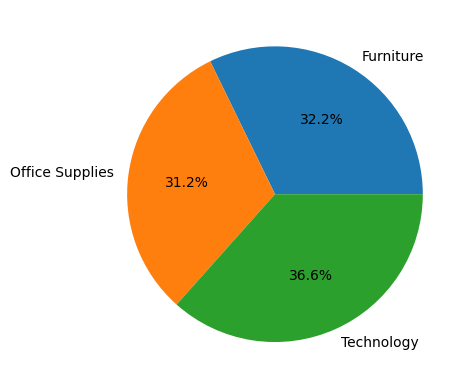

In [67]:

plt.pie(products_category['Total Sales'], labels=products_category['Category'], autopct='%1.1f%%')

           Category Sub-Category  Total Sales
8   Office Supplies    Fasteners    3001.9600
9   Office Supplies       Labels   12347.7260
7   Office Supplies    Envelopes   16128.0460
5   Office Supplies          Art   26705.4100
12  Office Supplies     Supplies   46420.3080
10  Office Supplies        Paper   76828.3040
2         Furniture  Furnishings   89212.0180
4   Office Supplies   Appliances  104618.4030
0         Furniture    Bookcases  113813.1987
14       Technology      Copiers  146248.0940
13       Technology  Accessories  164186.7000
15       Technology     Machines  189238.6310
6   Office Supplies      Binders  200028.7850
3         Furniture       Tables  202810.6280
11  Office Supplies      Storage  219343.3920
1         Furniture       Chairs  322822.7310
16       Technology       Phones  327782.4480


<BarContainer object of 17 artists>

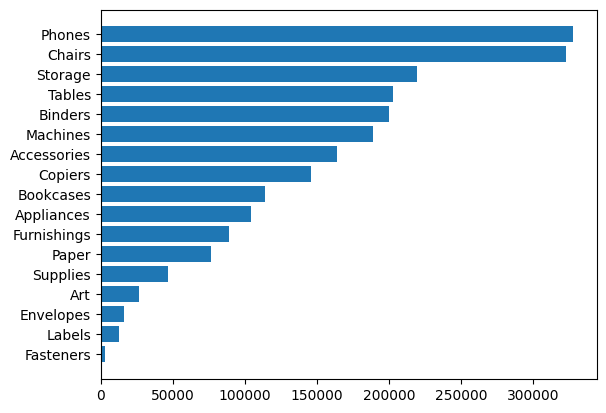

In [73]:
subcategory_count_sales = df.groupby(['Category','Sub-Category'])['Sales'].sum().reset_index().sort_values(by='Sales', ascending=True)
subcategory_count_sales.rename(columns={'Sales': 'Total Sales'}, inplace=True)
print(subcategory_count_sales)


plt.barh(subcategory_count_sales['Sub-Category'], subcategory_count_sales['Total Sales'])

In [88]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

yearly_sales = df.groupby(df['Order Date'].dt.year)['Sales'].sum().reset_index()
yearly_sales.rename(columns={'Order Date': 'Year', 'Sales': 'Total Sales'}, inplace=True)
print(yearly_sales)

   Year  Total Sales
0  2015  479856.2081
1  2016  459436.0054
2  2017  600192.5500
3  2018  722052.0192


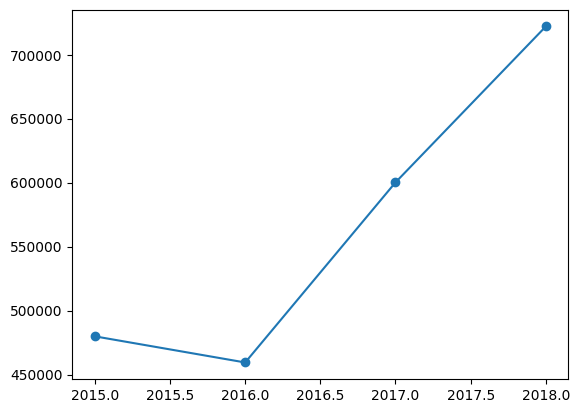

In [97]:
plt.plot(yearly_sales['Year'], yearly_sales['Total Sales'], marker='o', linestyle='-')

In [100]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
yearly_sales = df[df['Order Date'].dt.year == 2018]
quarterly_sales = yearly_sales.resample('QE', on='Order Date')['Sales'].sum().reset_index()
quarterly_sales.rename(columns={'Order Date': 'Quarter', 'Sales': 'Total Sales'}, inplace=True)
print(quarterly_sales)

     Quarter  Total Sales
0 2018-03-31  122260.8842
1 2018-06-30  127558.6200
2 2018-09-30  193815.8400
3 2018-12-31  278416.6750


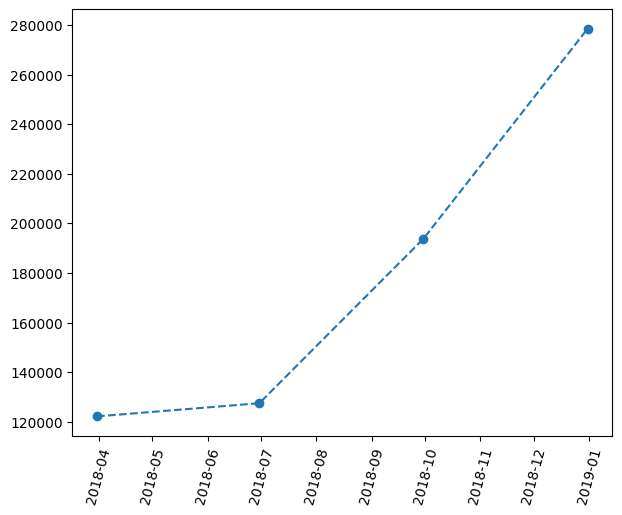

In [106]:
plt.plot(quarterly_sales['Quarter'], quarterly_sales['Total Sales'], marker='o', linestyle='--')

plt.tight_layout()

plt.xticks(rotation=75)

plt.show()

In [110]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
yearly_sales = df[df['Order Date'].dt.year == 2018]
monthly_sales = yearly_sales.resample('ME', on='Order Date')['Sales'].sum().reset_index()
monthly_sales.rename(columns={'Order Date': 'Month', 'Sales': 'Total Sales'}, inplace=True)
print(monthly_sales)

        Month  Total Sales
0  2018-01-31   43476.4740
1  2018-02-28   19920.9974
2  2018-03-31   58863.4128
3  2018-04-30   35541.9101
4  2018-05-31   43825.9822
5  2018-06-30   48190.7277
6  2018-07-31   44825.1040
7  2018-08-31   62837.8480
8  2018-09-30   86152.8880
9  2018-10-31   77448.1312
10 2018-11-30  117938.1550
11 2018-12-31   83030.3888


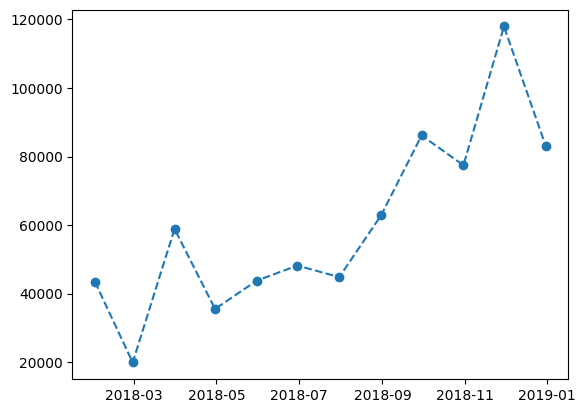

In [113]:
plt.plot(monthly_sales['Month'], monthly_sales['Total Sales'], marker='o', linestyle='--')



In [122]:

#create a mapping for all 50 states
all_state_mapping = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DF",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
}

In [124]:
#add the abbreviatio column to the dataframe
df['abbreviation'] = df['State'].map(all_state_mapping)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,abbreviatio,abbreviation
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,KY,KY
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,KY,KY
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,CA,CA
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,FL,FL
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,FL,FL


In [134]:
#group by state and calculate the sum of sales
sum_of_sales = df.groupby(['State', 'abbreviation'])['Sales'].sum().reset_index().rename(columns={'Sales': 'Total Sales'})

sum_of_sales.head()

,State,abbreviation,Total Sales
0,Alabama,AL,19510.6400
1,Arizona,AZ,35272.6570
2,Arkansas,AR,11678.1300
3,California,CA,446306.4635
4,Colorado,CO,31841.5980


In [145]:
#Create a choropleth map using plotly

fig = go.Figure(data=go.Choropleth(
    locations=sum_of_sales['abbreviation'],
    z=sum_of_sales['Total Sales'],
    locationmode='USA-states',
    colorscale='Greens',
    colorbar_title='Total Sales',
))

fig.update_layout(
    title_text='Total Sales by State',
    geo_scope='usa',
)

fig.show()

In [150]:
import plotly.express as px

#summarize the sales data by category and sub category
df_summary = df.groupby(['Category', 'Sub-Category'])['Sales'].sum().reset_index()

#create a nested pie chart
fig = px.sunburst(
    df_summary, path=['Category', 'Sub-Category'], values='Sales',
    # color='Sales', color_continuous_scale='Greens',
    title='Sales by Category and Sub-Category'
)

fig.show()